# Encoder–Decoder Architectures and Attention

This notebook includes:
1. Conceptual explanation of the **encoder–decoder architecture**
2. Figures showing how information flows through the model
3. Discussion of how **CNNs, RNNs, and LSTMs** can be used as encoders/decoders
4. A worked **sequence-to-sequence** example with PyTorch
5. Assignment prompts for **image captioning** and **question answering**
6. A section on **attention**, including code that **learns attention parameters**

---

## Learning goals
By the end of this notebook, you should be able to:
- Explain what an encoder and a decoder do
- Distinguish between fixed-context seq2seq and attention-based seq2seq
- Identify when CNNs, RNNs, and LSTMs are good encoder/decoder choices
- Train a simple attention-based model in PyTorch
- Design encoder–decoder systems for image captioning and question answering

## Why encoder–decoder models?
Many machine learning problems can be framed as:

**Input structure → compressed representation → output structure**

Examples:
- Sentence in French → sentence in English
- Image → caption
- Passage + question → answer
- Speech signal → text

The **encoder** reads the input and converts it into hidden representations.
The **decoder** uses those representations to generate the output.

A useful way to think about it:
- The encoder answers: **"What is in the input?"**
- The decoder answers: **"What should I generate next?"**

In [1]:
import math
import random
from collections import Counter

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, ArrowStyle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Figure 1: Basic encoder–decoder idea
The classic seq2seq model converts an input sequence into a context representation, then unfolds an output sequence.

In the earliest encoder–decoder models, the entire input was often compressed into a **single context vector**.  
That works for short sequences, but becomes difficult for longer inputs.

## What can play the role of encoder or decoder?

### 1. RNN / GRU / LSTM as an encoder
These are common when the input is a sequence:
- machine translation
- speech
- time series
- text classification

The encoder reads tokens one-by-one and updates its hidden state.

### 2. RNN / GRU / LSTM as a decoder
These are common when the output is sequential:
- translation
- caption generation
- dialog generation
- structured text output

The decoder predicts one token at a time.

### 3. CNN as an encoder
CNNs are natural for **images**, because they extract spatial features.
Examples:
- image captioning: image → caption
- visual question answering: image + question → answer
- OCR or scene text recognition pipelines

A CNN can also encode sequences using **1D convolutions**.

### 4. CNN as a decoder
CNN decoders appear when the output has spatial structure:
- segmentation masks
- image reconstruction
- image generation
- super-resolution

Examples often use **transpose convolutions** or upsampling blocks.

### 5. Hybrid models
Many real systems are hybrid:
- **CNN encoder + LSTM decoder** for image captioning
- **RNN encoder + RNN decoder** for translation
- **CNN encoder + Transformer decoder**
- **Transformer encoder + Transformer decoder**

## A small but important limitation of the original seq2seq model
In the earliest encoder–decoder approach, the encoder often produced one final hidden state that acted as a single summary vector.

This creates a **bottleneck**:
- short sequences may work fine
- long sequences become harder
- the decoder may lose access to detailed earlier information

That limitation is one main reason **attention** became so important.

# Part A — A simple seq2seq dataset example

To keep the notebook classroom-friendly and easy to run, we use a **toy sequence transduction dataset**.

### Task
Convert an input sequence of digits written as words into the reversed sequence.

Example:
- input: `"one two three"`
- output: `"three two one"`

This is useful because:
- it is a real sequence-to-sequence problem
- output length can vary
- the decoder must depend on the encoded input
- we can compare non-attention and attention ideas clearly

In [2]:
digit_words = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

def make_example(min_len=3, max_len=7):
    L = random.randint(min_len, max_len)
    seq = [random.choice(digit_words) for _ in range(L)]
    src = seq
    tgt = list(reversed(seq))
    return src, tgt

pairs = [make_example() for _ in range(2000)]
pairs[:5]

[(['two', 'six', 'zero', 'one', 'eight'],
  ['eight', 'one', 'zero', 'six', 'two']),
 (['five', 'nine', 'zero'], ['zero', 'nine', 'five']),
 (['three', 'zero', 'one', 'six', 'six', 'one', 'three'],
  ['three', 'one', 'six', 'six', 'one', 'zero', 'three']),
 (['eight', 'six', 'zero'], ['zero', 'six', 'eight']),
 (['one', 'three', 'nine', 'zero', 'nine', 'nine', 'six'],
  ['six', 'nine', 'nine', 'zero', 'nine', 'three', 'one'])]

In [3]:
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>"]
vocab = SPECIALS + digit_words
stoi = {tok: i for i, tok in enumerate(vocab)}
itos = {i: tok for tok, i in stoi.items()}

PAD_IDX = stoi["<pad>"]
SOS_IDX = stoi["<sos>"]
EOS_IDX = stoi["<eos>"]
UNK_IDX = stoi["<unk>"]

def encode_tokens(tokens):
    return [stoi.get(tok, UNK_IDX) for tok in tokens]

def decode_indices(indices):
    tokens = []
    for idx in indices:
        tok = itos[int(idx)]
        if tok == "<eos>":
            break
        if tok not in ("<sos>", "<pad>"):
            tokens.append(tok)
    return tokens

class ToySeq2SeqDataset(Dataset):
    def __init__(self, pairs):
        self.data = []
        for src, tgt in pairs:
            src_ids = encode_tokens(src) + [EOS_IDX]
            tgt_ids = [SOS_IDX] + encode_tokens(tgt) + [EOS_IDX]
            self.data.append((src_ids, tgt_ids))
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def collate_batch(batch):
    srcs, tgts = zip(*batch)
    max_src = max(len(x) for x in srcs)
    max_tgt = max(len(x) for x in tgts)

    src_tensor = torch.full((len(batch), max_src), PAD_IDX, dtype=torch.long)
    tgt_tensor = torch.full((len(batch), max_tgt), PAD_IDX, dtype=torch.long)

    for i, (src, tgt) in enumerate(zip(srcs, tgts)):
        src_tensor[i, :len(src)] = torch.tensor(src)
        tgt_tensor[i, :len(tgt)] = torch.tensor(tgt)

    return src_tensor, tgt_tensor

random.shuffle(pairs)
train_pairs = pairs[:1600]
val_pairs = pairs[1600:]

train_ds = ToySeq2SeqDataset(train_pairs)
val_ds = ToySeq2SeqDataset(val_pairs)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_batch)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_batch)

len(train_ds), len(val_ds), len(vocab)

(1600, 400, 14)

## Baseline: LSTM encoder + LSTM decoder
This is the classic encoder–decoder setup:
- the **encoder LSTM** reads the input sequence
- the **decoder LSTM** generates the output sequence one step at a time
- the decoder is initialized using the encoder's final state

Below we implement a compact version.

In [4]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, src):
        emb = self.embedding(src)
        outputs, (hidden, cell) = self.lstm(emb)
        return outputs, hidden, cell

class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(emb_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, input_tokens, hidden, cell):
        # input_tokens: [B]
        emb = self.embedding(input_tokens).unsqueeze(1)   # [B,1,E]
        out, (hidden, cell) = self.lstm(emb, (hidden, cell))
        logits = self.fc_out(out.squeeze(1))
        return logits, hidden, cell

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = len(vocab)
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)

        _, hidden, cell = self.encoder(src)
        input_tokens = tgt[:, 0]  # <sos>

        for t in range(1, tgt_len):
            logits, hidden, cell = self.decoder(input_tokens, hidden, cell)
            outputs[:, t] = logits
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_tokens = tgt[:, t] if teacher_force else top1

        return outputs

encoder = Encoder(len(vocab)).to(device)
decoder = Decoder(len(vocab)).to(device)
baseline_model = Seq2Seq(encoder, decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(baseline_model.parameters(), lr=0.003)

print(sum(p.numel() for p in baseline_model.parameters()))

202254


In [5]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output = model(src, tgt, teacher_forcing_ratio=0.6)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        output = model(src, tgt, teacher_forcing_ratio=0.0)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

baseline_history = {"train": [], "val": []}
for epoch in range(1, 9):
    tr = train_epoch(baseline_model, train_loader, optimizer, criterion)
    va = evaluate_epoch(baseline_model, val_loader, criterion)
    baseline_history["train"].append(tr)
    baseline_history["val"].append(va)
    print(f"Epoch {epoch:02d} | train loss={tr:.4f} | val loss={va:.4f}")

Epoch 01 | train loss=2.0724 | val loss=1.5872
Epoch 02 | train loss=1.3451 | val loss=1.3294
Epoch 03 | train loss=1.0235 | val loss=1.1232
Epoch 04 | train loss=0.8685 | val loss=0.8990
Epoch 05 | train loss=0.6086 | val loss=0.6858
Epoch 06 | train loss=0.4658 | val loss=0.5265
Epoch 07 | train loss=0.3133 | val loss=0.4133
Epoch 08 | train loss=0.2364 | val loss=0.3262


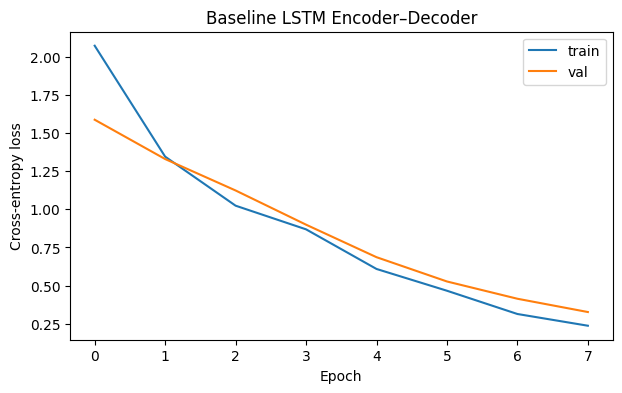

In [6]:
plt.figure(figsize=(7,4))
plt.plot(baseline_history["train"], label="train")
plt.plot(baseline_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Baseline LSTM Encoder–Decoder")
plt.legend()
plt.show()

In [7]:
@torch.no_grad()
def greedy_decode_baseline(model, src_tokens, max_len=15):
    model.eval()
    src = torch.tensor([encode_tokens(src_tokens) + [EOS_IDX]], dtype=torch.long, device=device)
    _, hidden, cell = model.encoder(src)

    input_tok = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
    generated = []
    for _ in range(max_len):
        logits, hidden, cell = model.decoder(input_tok, hidden, cell)
        next_tok = logits.argmax(1)
        idx = int(next_tok.item())
        if idx == EOS_IDX:
            break
        generated.append(idx)
        input_tok = next_tok
    return decode_indices(generated)

examples = [
    ["one", "two", "three"],
    ["seven", "zero", "four", "two"],
    ["nine", "nine", "one", "three", "zero"],
]

for ex in examples:
    pred = greedy_decode_baseline(baseline_model, ex)
    print("input :", ex)
    print("pred  :", pred)
    print("truth :", list(reversed(ex)))
    print("-" * 50)

input : ['one', 'two', 'three']
pred  : ['three', 'two', 'one', 'two', 'one']
truth : ['three', 'two', 'one']
--------------------------------------------------
input : ['seven', 'zero', 'four', 'two']
pred  : ['two', 'four', 'zero', 'seven', 'zero', 'seven']
truth : ['two', 'four', 'zero', 'seven']
--------------------------------------------------
input : ['nine', 'nine', 'one', 'three', 'zero']
pred  : ['zero', 'three', 'nine', 'one', 'nine', 'nine']
truth : ['zero', 'three', 'one', 'nine', 'nine']
--------------------------------------------------


## Interpreting the baseline
The baseline learns the task because the input and output are strongly related.
However, for longer or more complex tasks, relying on a **single final encoder state** becomes limiting.

That leads us to **attention**.

# Part B — Attention mechanism

## Idea
Instead of forcing the decoder to rely on only one compressed context vector, let it look back at **all encoder hidden states**.

At decoder step \(t\):
1. compare current decoder state with encoder states
2. compute a score for each encoder position
3. normalize those scores into attention weights
4. build a weighted sum of encoder states
5. use that context to predict the next token

This makes the model more flexible, especially for longer inputs.

## Figure 3: Encoder–decoder with attention

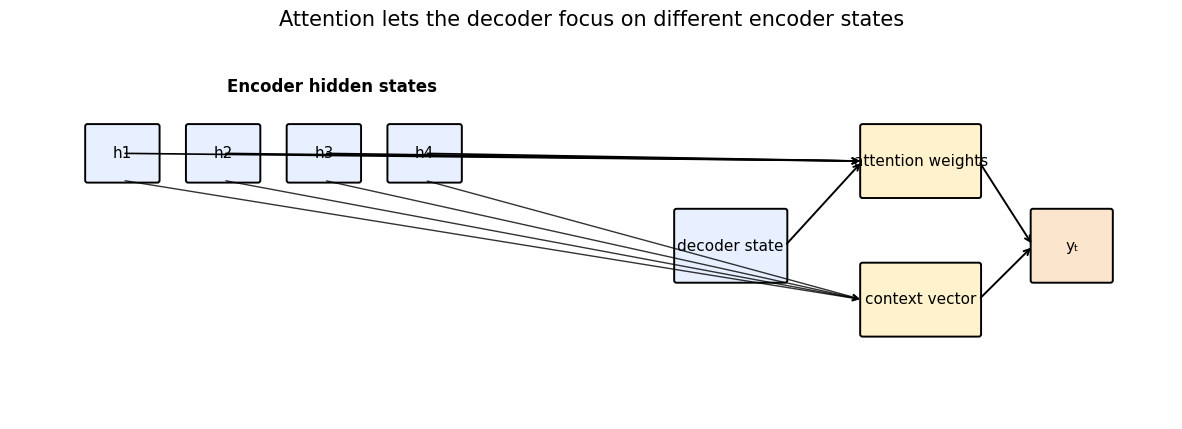

In [10]:
def draw_attention_figure():
    fig, ax = plt.subplots(figsize=(15, 5))
    ax.set_xlim(0, 15)
    ax.set_ylim(0, 5)
    ax.axis("off")

    def box(x, y, w, h, txt, fc="#f5f5f5"):
        ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.03",
                                    linewidth=1.4, facecolor=fc, edgecolor="black"))
        ax.text(x + w/2, y + h/2, txt, ha="center", va="center", fontsize=11)

    enc_x = [1.0, 2.3, 3.6, 4.9]
    for i, x in enumerate(enc_x, 1):
        box(x, 3.1, 0.9, 0.7, f"h{i}", fc="#e8f0ff")

    box(8.6, 1.8, 1.4, 0.9, "decoder state", fc="#e8f0ff")
    box(11.0, 2.9, 1.5, 0.9, "attention weights", fc="#fff2cc")
    box(11.0, 1.1, 1.5, 0.9, "context vector", fc="#fff2cc")
    box(13.2, 1.8, 1.0, 0.9, "yₜ", fc="#fce5cd")

    for x in enc_x:
        ax.annotate("", xy=(11.0, 3.35), xytext=(x + 0.45, 3.45),
                    arrowprops=dict(arrowstyle="->", linewidth=1.2))
        ax.annotate("", xy=(11.0, 1.55), xytext=(x + 0.45, 3.1),
                    arrowprops=dict(arrowstyle="->", linewidth=1.0, alpha=0.8))

    ax.annotate("", xy=(11.0, 3.35), xytext=(10.0, 2.25), arrowprops=dict(arrowstyle="->", linewidth=1.4))
    ax.annotate("", xy=(13.2, 2.25), xytext=(12.5, 1.55), arrowprops=dict(arrowstyle="->", linewidth=1.4))
    ax.annotate("", xy=(13.2, 2.25), xytext=(12.5, 3.35), arrowprops=dict(arrowstyle="->", linewidth=1.4))

    ax.text(2.8, 4.25, "Encoder hidden states", fontsize=12, weight="bold")
    ax.set_title("Attention lets the decoder focus on different encoder states", fontsize=15)
    plt.show()

draw_attention_figure()

## 6. A Common Additive Attention Formulation

Additive attention (also known as **Bahdanau Attention**) allows the decoder to focus on different parts of the input sequence at each step of the output generation.

### 🔹 Step 1: The Alignment Score
For each encoder hidden state $h_i$ (where $i$ is the position in the input) and the current decoder hidden state $s_t$, we compute an energy score $e_{t,i}$. This score represents how well the input at position $i$ matches the current needs of the decoder at step $t$:

$$e_{t,i} = v^\top \tanh(W_h h_i + W_s s_t)$$

---

### 🔹 Step 2: The Attention Weights (Normalization)
We convert these raw scores into probabilities using a **Softmax** function. This ensures that all weights are between 0 and 1 and sum to 1:

$$\alpha_{t,i} = \text{softmax}(e_{t,i}) = \frac{\exp(e_{t,i})}{\sum_{j=1}^{T} \exp(e_{t,j})}$$

These $\alpha_{t,i}$ values tell the model which specific input words are most important for the current output word.

---

### 🔹 Step 3: The Context Vector
Finally, we compute the **context vector** $c_t$ as a weighted sum of the encoder hidden states. This vector acts as a "summary" of the input, filtered by the attention weights:

$$c_t = \sum_{i=1}^{T} \alpha_{t,i} h_i$$



---

### 🔹 Key Learnable Parameters
The intelligence of this mechanism lies in three parameters that are learned via backpropagation:
* **$W_h$**: A weight matrix that transforms the encoder states.
* **$W_s$**: A weight matrix that transforms the decoder state.
* **$v$**: A weight vector that collapses the combined representation into a single scalar score.

> **Intuition:** The model learns to "ask" for specific information ($W_s s_t$) and the encoder learns to "provide" it in a compatible format ($W_h h_i$).

## Attention model implementation in PyTorch
Below, we replace the fixed single-vector bottleneck with a learned attention module.

In [11]:
class AdditiveAttention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.W_h = nn.Linear(hid_dim, hid_dim, bias=False)
        self.W_s = nn.Linear(hid_dim, hid_dim, bias=False)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs, src_mask=None):
        # decoder_hidden: [B, H]
        # encoder_outputs: [B, S, H]
        dec = decoder_hidden.unsqueeze(1).repeat(1, encoder_outputs.size(1), 1)
        energy = torch.tanh(self.W_h(encoder_outputs) + self.W_s(dec))
        scores = self.v(energy).squeeze(-1)  # [B, S]

        if src_mask is not None:
            scores = scores.masked_fill(~src_mask, -1e9)

        attn_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B,H]
        return context, attn_weights

class AttnDecoder(nn.Module):
    def __init__(self, vocab_size, emb_dim=64, hid_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.attention = AdditiveAttention(hid_dim)
        self.lstm = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim * 2, vocab_size)

    def forward(self, input_tokens, hidden, cell, encoder_outputs, src_mask=None):
        emb = self.embedding(input_tokens)                       # [B,E]
        dec_hidden = hidden[-1]                                 # [B,H]
        context, attn_weights = self.attention(dec_hidden, encoder_outputs, src_mask)
        lstm_input = torch.cat([emb, context], dim=1).unsqueeze(1)  # [B,1,E+H]
        out, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        logits = self.fc_out(torch.cat([out.squeeze(1), context], dim=1))
        return logits, hidden, cell, attn_weights

class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def make_src_mask(self, src):
        return src != PAD_IDX

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        batch_size, tgt_len = tgt.shape
        vocab_size = len(vocab)

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)
        attn_store = []

        encoder_outputs, hidden, cell = self.encoder(src)
        src_mask = self.make_src_mask(src)
        input_tokens = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden, cell, attn_weights = self.decoder(
                input_tokens, hidden, cell, encoder_outputs, src_mask
            )
            outputs[:, t] = logits
            attn_store.append(attn_weights.detach().cpu())
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = logits.argmax(1)
            input_tokens = tgt[:, t] if teacher_force else top1

        return outputs, attn_store

attn_encoder = Encoder(len(vocab)).to(device)
attn_decoder = AttnDecoder(len(vocab)).to(device)
attn_model = AttnSeq2Seq(attn_encoder, attn_decoder).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
attn_optimizer = optim.Adam(attn_model.parameters(), lr=0.003)

In [12]:
def train_epoch_attn(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        optimizer.zero_grad()
        output, _ = model(src, tgt, teacher_forcing_ratio=0.6)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

@torch.no_grad()
def evaluate_epoch_attn(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)
        output, _ = model(src, tgt, teacher_forcing_ratio=0.0)
        loss = criterion(output[:, 1:].reshape(-1, len(vocab)),
                         tgt[:, 1:].reshape(-1))
        total_loss += loss.item()
    return total_loss / len(loader)

attn_history = {"train": [], "val": []}
for epoch in range(1, 9):
    tr = train_epoch_attn(attn_model, train_loader, attn_optimizer, criterion)
    va = evaluate_epoch_attn(attn_model, val_loader, criterion)
    attn_history["train"].append(tr)
    attn_history["val"].append(va)
    print(f"Epoch {epoch:02d} | train loss={tr:.4f} | val loss={va:.4f}")

Epoch 01 | train loss=1.8267 | val loss=1.2595
Epoch 02 | train loss=0.8091 | val loss=0.3195
Epoch 03 | train loss=0.1959 | val loss=0.0974
Epoch 04 | train loss=0.0479 | val loss=0.0396
Epoch 05 | train loss=0.0278 | val loss=0.0264
Epoch 06 | train loss=0.0492 | val loss=0.0206
Epoch 07 | train loss=0.0143 | val loss=0.0186
Epoch 08 | train loss=0.0075 | val loss=0.0034


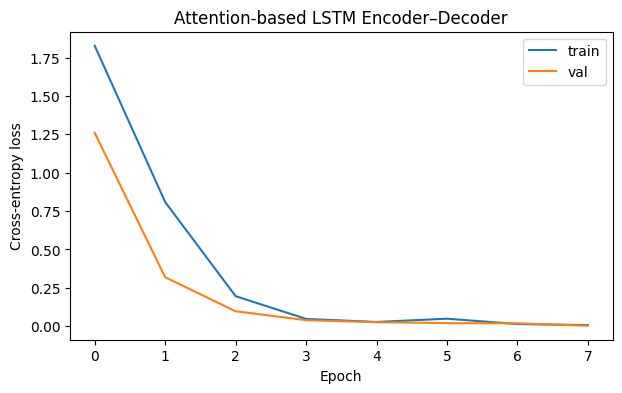

In [13]:
plt.figure(figsize=(7,4))
plt.plot(attn_history["train"], label="train")
plt.plot(attn_history["val"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("Attention-based LSTM Encoder–Decoder")
plt.legend()
plt.show()

In [14]:
@torch.no_grad()
def greedy_decode_attn(model, src_tokens, max_len=15):
    model.eval()
    src_ids = encode_tokens(src_tokens) + [EOS_IDX]
    src = torch.tensor([src_ids], dtype=torch.long, device=device)
    encoder_outputs, hidden, cell = model.encoder(src)
    src_mask = model.make_src_mask(src)

    input_tok = torch.tensor([SOS_IDX], dtype=torch.long, device=device)
    generated = []
    all_attn = []

    for _ in range(max_len):
        logits, hidden, cell, attn = model.decoder(input_tok, hidden, cell, encoder_outputs, src_mask)
        next_tok = logits.argmax(1)
        idx = int(next_tok.item())
        all_attn.append(attn.squeeze(0).detach().cpu())
        if idx == EOS_IDX:
            break
        generated.append(idx)
        input_tok = next_tok
    return decode_indices(generated), torch.stack(all_attn)

for ex in examples:
    pred, attn = greedy_decode_attn(attn_model, ex)
    print("input :", ex)
    print("pred  :", pred)
    print("truth :", list(reversed(ex)))
    print("attention matrix shape:", tuple(attn.shape))
    print("-" * 50)

input : ['one', 'two', 'three']
pred  : ['three', 'three', 'three', 'two', 'one']
truth : ['three', 'two', 'one']
attention matrix shape: (6, 4)
--------------------------------------------------
input : ['seven', 'zero', 'four', 'two']
pred  : ['two', 'two', 'two', 'four', 'zero', 'seven']
truth : ['two', 'four', 'zero', 'seven']
attention matrix shape: (7, 5)
--------------------------------------------------
input : ['nine', 'nine', 'one', 'three', 'zero']
pred  : ['zero', 'zero', 'zero', 'three', 'nine', 'nine']
truth : ['zero', 'three', 'one', 'nine', 'nine']
attention matrix shape: (7, 6)
--------------------------------------------------


## Visualizing learned attention weights
The following heatmap shows which input positions the decoder focused on while generating each output token.

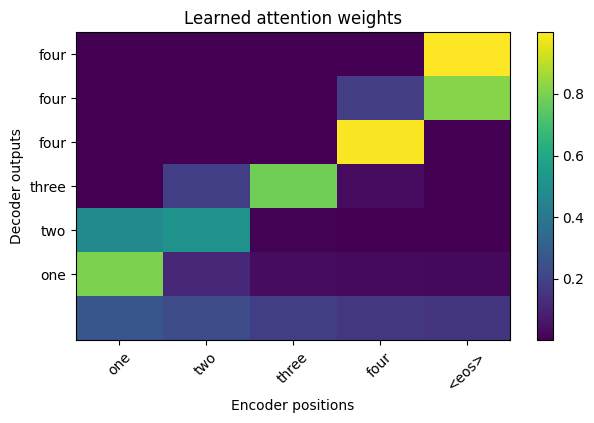

input : ['one', 'two', 'three', 'four']
pred  : ['four', 'four', 'four', 'three', 'two', 'one']
truth : ['four', 'three', 'two', 'one']


In [15]:
test_seq = ["one", "two", "three", "four"]
pred_tokens, attn = greedy_decode_attn(attn_model, test_seq)

plt.figure(figsize=(7,4))
plt.imshow(attn.numpy(), aspect="auto")
plt.xticks(range(len(test_seq) + 1), test_seq + ["<eos>"], rotation=45)
plt.yticks(range(len(pred_tokens)), pred_tokens)
plt.xlabel("Encoder positions")
plt.ylabel("Decoder outputs")
plt.title("Learned attention weights")
plt.colorbar()
plt.show()

print("input :", test_seq)
print("pred  :", pred_tokens)
print("truth :", list(reversed(test_seq)))

## Where are the attention parameters learned?
In the `AdditiveAttention` module above, the learnable parameters are:

- `self.W_h`
- `self.W_s`
- `self.v`

They are ordinary PyTorch layers, so they are trained automatically during:
1. forward pass
2. loss computation
3. backpropagation with `.backward()`
4. optimizer update with `.step()`

We can inspect them directly:

In [16]:
for name, param in attn_model.decoder.attention.named_parameters():
    print(name, tuple(param.shape), "requires_grad=", param.requires_grad)

W_h.weight (128, 128) requires_grad= True
W_s.weight (128, 128) requires_grad= True
v.weight (1, 128) requires_grad= True


# Part C — How CNN, RNN, and LSTM fit into encoder–decoder systems

## 1. RNN / LSTM encoder + RNN / LSTM decoder
**Use case:** machine translation, text summarization, conversational modeling, speech-to-text

- Encoder processes source sequence
- Decoder generates target sequence
- Attention often improves performance

## 2. CNN encoder + LSTM decoder
**Use case:** image captioning

- CNN converts image into visual features
- Decoder LSTM generates words
- Attention can focus on image regions

## 3. CNN encoder + CNN decoder
**Use case:** segmentation, image reconstruction

- Encoder compresses spatial information
- Decoder upsamples into output image or mask

## 4. LSTM encoder + classifier decoder
**Use case:** sequence classification

This is not always a full autoregressive decoder, but the encoder–decoder perspective still helps explain the flow of information.

## 5. Encoder–decoder for question answering
There are multiple variants:
- passage encoder + question encoder + answer decoder
- encoder-only extractive QA
- encoder–decoder generative QA
- multimodal QA using image encoder + text decoder

# Part D — Example application sketches

## Image captioning
A common classical pipeline is:

**Image → CNN encoder → visual embedding(s) → LSTM decoder → caption**

Typical datasets:
- Flickr8k
- Flickr30k
- MS COCO

The CNN provides image features, and the LSTM generates a sentence such as:
> "a dog running through grass"

Below is a simple skeleton architecture.

In [17]:
class ImageCaptioningSkeleton(nn.Module):
    def __init__(self, image_feat_dim=512, vocab_size=5000, emb_dim=256, hid_dim=512):
        super().__init__()
        self.image_proj = nn.Linear(image_feat_dim, hid_dim)
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.decoder = nn.LSTM(emb_dim + hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, image_features, captions_in):
        # image_features: [B, image_feat_dim]
        # captions_in: [B, T]
        image_context = self.image_proj(image_features).unsqueeze(1)   # [B,1,H]
        word_emb = self.embedding(captions_in)                         # [B,T,E]
        repeated_context = image_context.repeat(1, word_emb.size(1), 1)
        dec_in = torch.cat([word_emb, repeated_context], dim=-1)
        out, _ = self.decoder(dec_in)
        logits = self.fc_out(out)
        return logits

dummy_image_feats = torch.randn(4, 512)
dummy_captions = torch.randint(0, 5000, (4, 6))
model = ImageCaptioningSkeleton()
logits = model(dummy_image_feats, dummy_captions)
print("captioning logits shape:", tuple(logits.shape))

captioning logits shape: (4, 6, 5000)


## Question answering
An encoder–decoder QA system can be framed as:

**[passage, question] → encoder → decoder → answer**

Examples:
- "Who wrote Hamlet?" → "Shakespeare"
- "What is the capital of France?" → "Paris"

A generative QA system can produce the answer token-by-token.
This is especially useful when:
- the answer is not a simple span copy
- the output must be natural language
- the task is abstractive

Below is a very small sketch of a text QA encoder–decoder.

In [18]:
class QASkeleton(nn.Module):
    def __init__(self, vocab_size=8000, emb_dim=128, hid_dim=256):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.encoder = nn.LSTM(emb_dim, hid_dim, batch_first=True, bidirectional=True)
        self.decoder = nn.LSTM(emb_dim + 2*hid_dim, hid_dim, batch_first=True)
        self.fc_out = nn.Linear(hid_dim, vocab_size)

    def forward(self, source_tokens, answer_prefix):
        src_emb = self.embedding(source_tokens)
        enc_outputs, _ = self.encoder(src_emb)
        context = enc_outputs.mean(dim=1, keepdim=True)   # simple pooled context
        ans_emb = self.embedding(answer_prefix)
        context_rep = context.repeat(1, ans_emb.size(1), 1)
        dec_in = torch.cat([ans_emb, context_rep], dim=-1)
        dec_out, _ = self.decoder(dec_in)
        logits = self.fc_out(dec_out)
        return logits

dummy_source = torch.randint(0, 8000, (3, 12))
dummy_prefix = torch.randint(0, 8000, (3, 5))
qa_model = QASkeleton()
qa_logits = qa_model(dummy_source, dummy_prefix)
print("QA logits shape:", tuple(qa_logits.shape))

QA logits shape: (3, 5, 8000)


# Part E — Assignments

## Assignment 1: Image Description Generation
Build an image captioning system using a **CNN encoder + LSTM decoder**.

### Task
Given an input image, generate a natural-language caption.

### Suggested dataset
- **Flickr8k** or **Flickr30k**

### Requirements
1. Use a pretrained CNN backbone (for example ResNet18 or ResNet50) as the encoder
2. Add a decoder based on LSTM or GRU
3. Train the model to generate captions
4. Evaluate using at least one caption metric (BLEU is a simple starting point)
5. Show 5 correct predictions and 5 failure cases
6. Explain what kinds of images the model struggles with


## Assignment 2: Question Answering with Encoder–Decoder
Build a generative QA model.

### Task
Given a context passage and a question, generate the answer.

### Suggested datasets
- **SQuAD** (for text QA)
- a small curated QA dataset made in class
- a synthetic QA dataset for low-compute experiments

### Requirements
1. Concatenate or otherwise combine passage and question
2. Use an encoder to build hidden representations
3. Use a decoder to generate the answer token-by-token
4. Compare performance with and without attention
5. Analyze at least 5 errors
